In [18]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [19]:
data = {
    'Credit_History': ['medium','medium','high','low','low','low','high',
                       'medium','medium','low','medium','high','high','low'],
    'Salary': ['high','high','high','medium','low','low','low',
               'medium','low','medium','medium','medium','high','medium'],
    'Property': ['no','yes','no','no','no','yes','yes',
                 'no','no','no','yes','yes','no','yes'],
    'Loan_Status': ['no','no','yes','yes','yes','no','yes',
                    'no','yes','yes','yes','yes','yes','no']
}

df = pd.DataFrame(data)

print(df)

   Credit_History  Salary Property Loan_Status
0          medium    high       no          no
1          medium    high      yes          no
2            high    high       no         yes
3             low  medium       no         yes
4             low     low       no         yes
5             low     low      yes          no
6            high     low      yes         yes
7          medium  medium       no          no
8          medium     low       no         yes
9             low  medium       no         yes
10         medium  medium      yes         yes
11           high  medium      yes         yes
12           high    high       no         yes
13            low  medium      yes          no


In [20]:
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nClass Distribution")
print(df["Loan_Status"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Credit_History  14 non-null     str  
 1   Salary          14 non-null     str  
 2   Property        14 non-null     str  
 3   Loan_Status     14 non-null     str  
dtypes: str(4)
memory usage: 580.0 bytes
None

Missing Values
Credit_History    0
Salary            0
Property          0
Loan_Status       0
dtype: int64

Class Distribution
Loan_Status
yes    9
no     5
Name: count, dtype: int64


In [21]:
le_credit = LabelEncoder()
le_salary = LabelEncoder()
le_property = LabelEncoder()
le_target = LabelEncoder()

df['Credit_History'] = le_credit.fit_transform(df['Credit_History'])
df['Salary'] = le_salary.fit_transform(df['Salary'])
df['Property'] = le_property.fit_transform(df['Property'])
df['Loan_Status'] = le_target.fit_transform(df['Loan_Status'])
print(df)

    Credit_History  Salary  Property  Loan_Status
0                2       0         0            0
1                2       0         1            0
2                0       0         0            1
3                1       2         0            1
4                1       1         0            1
5                1       1         1            0
6                0       1         1            1
7                2       2         0            0
8                2       1         0            1
9                1       2         0            1
10               2       2         1            1
11               0       2         1            1
12               0       0         0            1
13               1       2         1            0


In [22]:
X = df[['Credit_History', 'Salary', 'Property']]
y = df['Loan_Status']

In [23]:
X_train, X_test,  y_train,y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0
)

In [24]:
clf = DecisionTreeClassifier(criterion='entropy', random_state=0)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [25]:
y_pred = clf.predict(X_test)
print(y_pred)

[0 1 0]


In [26]:
clf.predict_proba(X_test)

array([[1., 0.],
       [0., 1.],
       [1., 0.]])

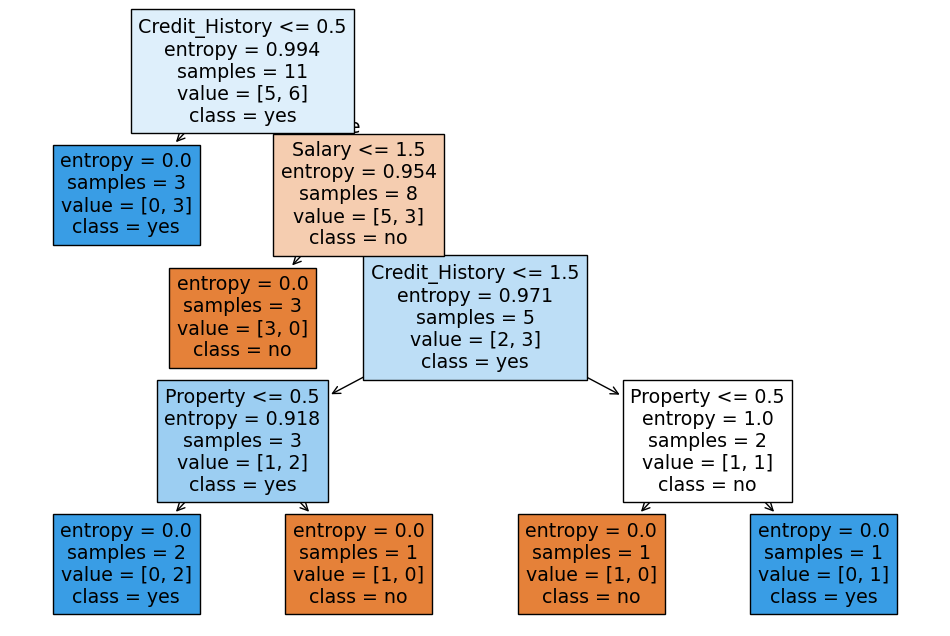

In [27]:
plt.figure(figsize=(12,8))

plot_tree(
    clf,
    feature_names=['Credit_History', 'Salary', 'Property'],
    class_names=['no', 'yes'],
    filled=True
)

plt.show()

In [31]:
# Credit_History = medium
# Salary = medium
# Property = yes

sample = [[2, 2, 1]]   

prediction = clf.predict(sample)

print("Prediction:", "yes" if prediction[0] == 1 else "no")

Prediction: yes


C:\Users\shiva\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [29]:
from sklearn.tree import export_text

rules = export_text(
    clf,
    feature_names=['Credit_History', 'Salary', 'Property']
)

print(rules)

|--- Credit_History <= 0.50
|   |--- class: 1
|--- Credit_History >  0.50
|   |--- Salary <= 1.50
|   |   |--- class: 0
|   |--- Salary >  1.50
|   |   |--- Credit_History <= 1.50
|   |   |   |--- Property <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Property >  0.50
|   |   |   |   |--- class: 0
|   |   |--- Credit_History >  1.50
|   |   |   |--- Property <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Property >  0.50
|   |   |   |   |--- class: 1

